In [1]:
### STEP 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# STEP 2: Load and Clean the Data
df = pd.read_csv("powergrid.csv")
df = df.drop(index=0)  # Drop the repeated header row
df['Date'] = pd.to_datetime(df['Date'])
cols_to_convert = ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.sort_values('Date')
df.reset_index(drop=True, inplace=True)

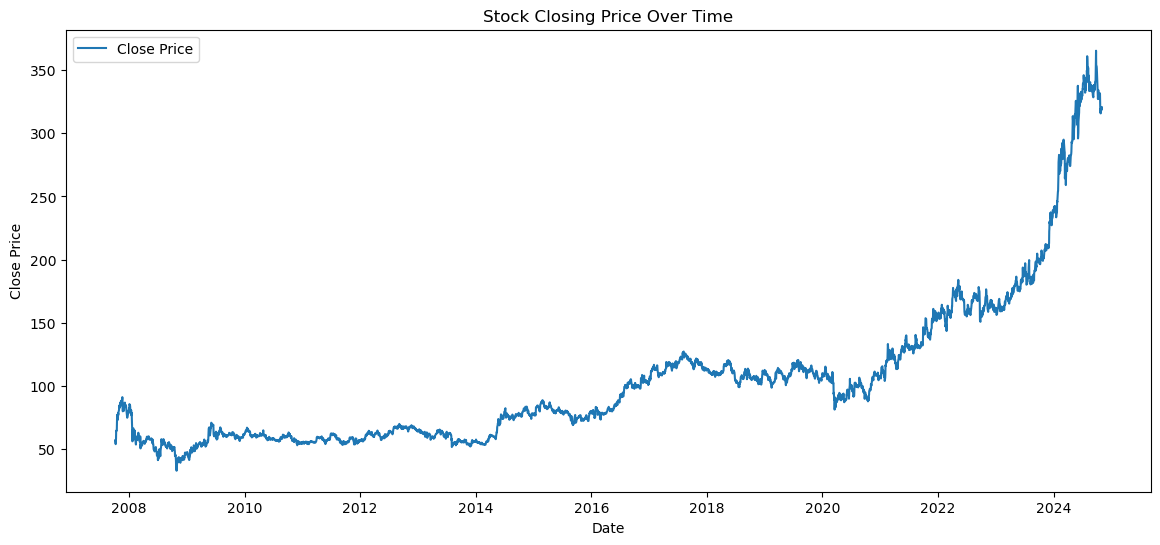

In [3]:
# STEP 3: Visualizations
# 1. Line Plot of Close Price
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [4]:
# 2. Moving Averages
df['MA30'] = df['Close'].rolling(window=30).mean()
df['MA100'] = df['Close'].rolling(window=100).mean()

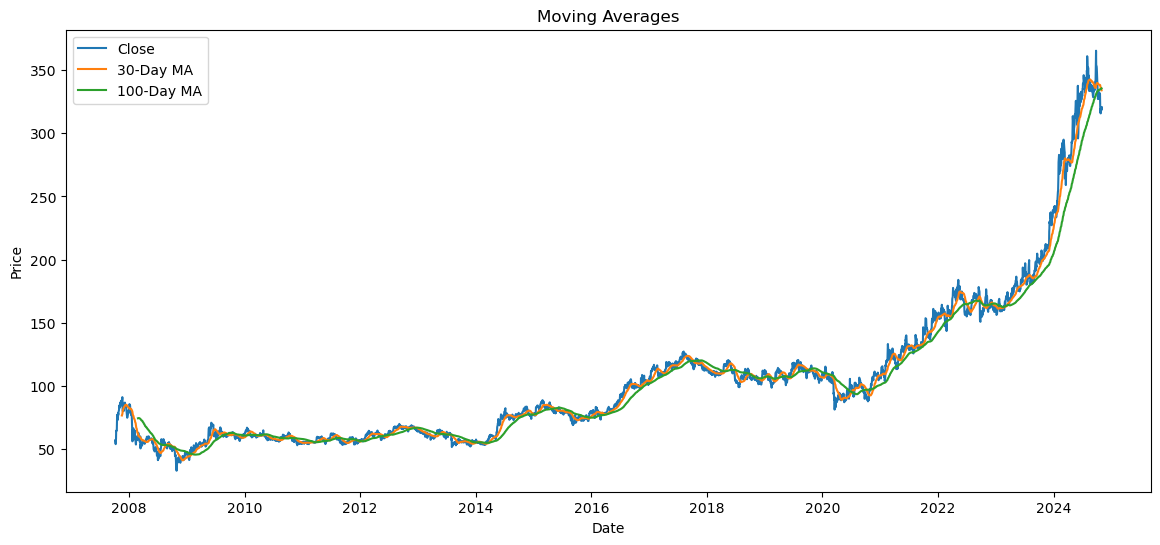

In [5]:
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['MA30'], label='30-Day MA')
plt.plot(df['Date'], df['MA100'], label='100-Day MA')
plt.title("Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

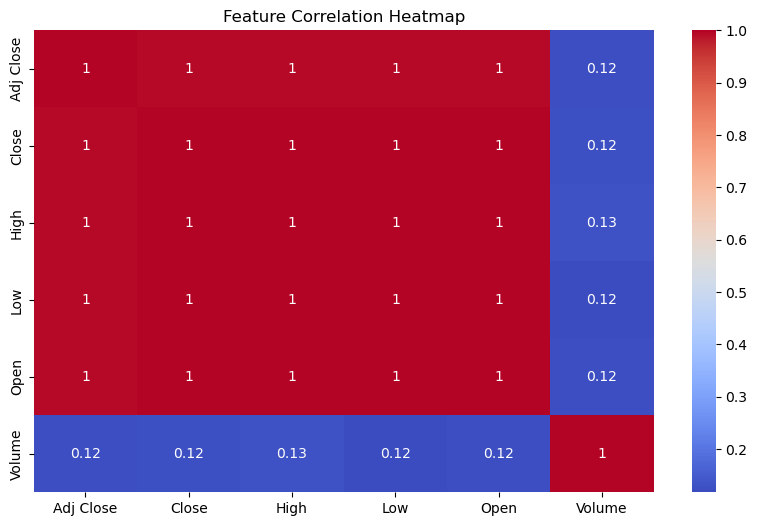

In [6]:
# 3. Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[cols_to_convert].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

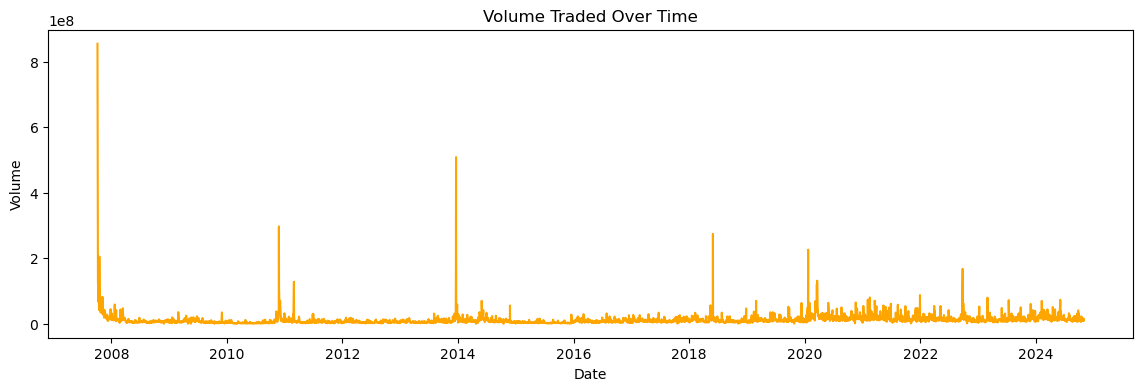

In [7]:
# 4. Volume Over Time
plt.figure(figsize=(14, 4))
plt.plot(df['Date'], df['Volume'], color='orange')
plt.title("Volume Traded Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

In [8]:
# STEP 4: Prepare Data for Linear Regression
# Use 'Open', 'High', 'Low', 'Volume' to predict 'Close'
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

In [9]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
# Predict
y_pred = model.predict(X_test)

In [12]:
# STEP 5: Evaluation
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.7337424042794027
R² Score: 0.9998078505887557


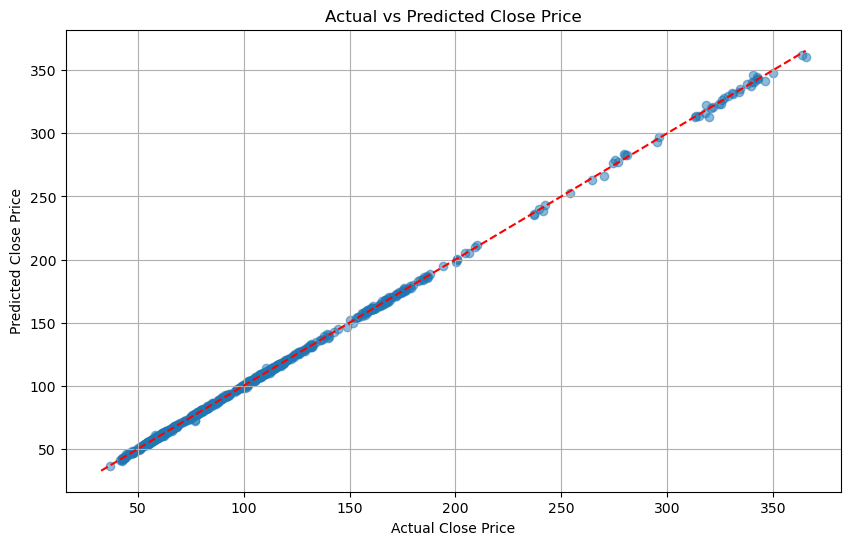

In [13]:
# Plot Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted Close Price")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Diagonal line
plt.grid(True)
plt.show()

In [14]:
# Compute MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
accuracy = 100 - mape

print(f"MAPE: {mape:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")


MAPE: 0.55%
Accuracy: 99.45%
